# Эксперимент 7: Полная демонстрация фреймворка

Проверка: все 4 сценария проходят через полный пайплайн.
Показываем что `DecisionEngine` выбирает правильный метод в каждом случае
и что выбранный метод превосходит baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys, os

sys.path.append(os.path.abspath('..'))

from ab_framework.data.generator import (
    EcommerceScenario, LowCorrelationScenario, RatioScenario, SegmentedScenario
)
from ab_framework.pipeline.runner import ABTestRunner

sns.set_theme(style='whitegrid', context='paper', font_scale=1.1)

N_USERS = 10_000
SEED    = 42
print('Готово к запуску.')


Готово к запуску.


In [ ]:
SCENARIOS = [
    {
        'name':      'E-commerce (rho≈0.46)',
        'expected':  'CUPED',
        'scenario':  EcommerceScenario(),  
        'config': {
            'target_metric':          'revenue',
            'group_column':           'group',
            'pre_experiment_metric':  'pre_revenue',
            'categorical_covariates': ['device_type', 'age_group'],
            'metric_type':            'continuous',
        },
        'effect_sizes': [0.0, 0.02, 0.05, 0.10],
    },
    {
        'name':      'Low Correlation (rho≈0.17)',
        'expected':  'Baseline t-test',
        'scenario':  LowCorrelationScenario(),  
        'config': {
            'target_metric':          'revenue',
            'group_column':           'group',
            'pre_experiment_metric':  'pre_revenue',
            'categorical_covariates': ['device_type', 'age_group'],
            'metric_type':            'continuous',
        },
        'effect_sizes': [0.0, 0.02, 0.05, 0.10],
    },
    {
        'name':      'Ratio Metric (ARPU)',
        'expected':  'Delta Method',
        'scenario':  RatioScenario(),
        'config': {
            'target_metric':      'revenue',
            'group_column':       'group',
            'denominator_metric': 'n_sessions',
            'categorical_covariates': ['device_type'],
            'metric_type':        'ratio',
        },
        'effect_sizes': [0.0, 0.02, 0.05, 0.10],
    },
    {
        'name':      'Segmented (iOS/Android/Web)',
        'expected':  'Post-Stratification',
        'scenario':  SegmentedScenario(),
        'config': {
            'target_metric':          'revenue',
            'group_column':           'group',
            'categorical_covariates': ['device_type'],
            'metric_type':            'continuous',
        },
        'effect_sizes': [0.0, 0.02, 0.05, 0.10],
    },
]
print(f'Настроено {len(SCENARIOS)} сценариев.')


Настроено 4 сценариев.


## Шаг 1: Запуск пайплайна для каждого сценария

In [8]:
results_all = []

for sc_cfg in SCENARIOS:
    sc_name = sc_cfg['name']
    print(f'\n {sc_name} ')
    for eff in sc_cfg['effect_sizes']:
        df = sc_cfg['scenario'].generate(N_USERS, effect_size=eff, seed=SEED)
        r  = ABTestRunner(df, sc_cfg['config']).run()
        results_all.append({
            'scenario':            sc_name,
            'expected_method':     sc_cfg['expected'],
            'effect_size':         eff,
            'method_used':         r['method_used'],
            'p_value':             r['p_value'],
            'is_significant':      r['is_significant'],
            'variance_reduction':  r['variance_reduction_pct'],
            'effect_estimate':     r['effect_estimate'],
        })
        sig = '✓ SIGNIFICANT' if r['is_significant'] else '  not signif.'
        print(f'  effect={eff:.2f}  p={r["p_value"]:.4f}  {sig}  [{r["method_used"]}]')

df_results = pd.DataFrame(results_all)
print('\nВсего запусков:', len(df_results))



 E-commerce (rho≈0.46) 
  effect=0.00  p=0.4183    not signif.  [standard_cuped + welch t-test]
  effect=0.02  p=0.6980    not signif.  [standard_cuped + welch t-test]
  effect=0.05  p=0.0323  ✓ SIGNIFICANT  [standard_cuped + welch t-test]
  effect=0.10  p=0.0000  ✓ SIGNIFICANT  [standard_cuped + welch t-test]

 Low Correlation (rho≈0.17) 
  effect=0.00  p=0.9237    not signif.  [none + welch t-test]
  effect=0.02  p=0.2459    not signif.  [none + welch t-test]
  effect=0.05  p=0.0065  ✓ SIGNIFICANT  [none + welch t-test]
  effect=0.10  p=0.0000  ✓ SIGNIFICANT  [none + welch t-test]

 Ratio Metric (ARPU) 
  effect=0.00  p=0.3061    not signif.  [delta method]
  effect=0.02  p=0.0083  ✓ SIGNIFICANT  [delta method]
  effect=0.05  p=0.0000  ✓ SIGNIFICANT  [delta method]
  effect=0.10  p=0.0000  ✓ SIGNIFICANT  [delta method]

 Segmented (iOS/Android/Web) 
  effect=0.00  p=0.2817    not signif.  [post_stratification + t-test]
  effect=0.02  p=0.9554    not signif.  [post_stratification + t

## Шаг 2: Проверка — DecisionEngine выбрал правильный метод?

Таблица показывает: ожидаемый метод vs фактически выбранный.

In [ ]:
METHOD_KEYWORDS = {
    'CUPED':              'cuped',
    'Baseline t-test':    'welch',
    'Delta Method':       'delta',
    'Post-Stratification':'stratif',
}

check = df_results[df_results['effect_size'] == 0.05][
    ['scenario', 'expected_method', 'method_used']
].drop_duplicates().copy()

check['ok'] = check.apply(
    lambda row: 'YES' if METHOD_KEYWORDS.get(
        row['expected_method'], row['expected_method'].lower()
    ) in row['method_used'].lower() else 'NO',
    axis=1
)
print(check.to_string(index=False))


                   scenario     expected_method                   method_used  ok
      E-commerce (rho≈0.46)               CUPED standard_cuped + welch t-test YES
 Low Correlation (rho≈0.17)     Baseline t-test           none + welch t-test YES
        Ratio Metric (ARPU)        Delta Method                  delta method YES
Segmented (iOS/Android/Web) Post-Stratification  post_stratification + t-test YES


## Шаг 3: Power Curve — зависимость p-value от размера эффекта

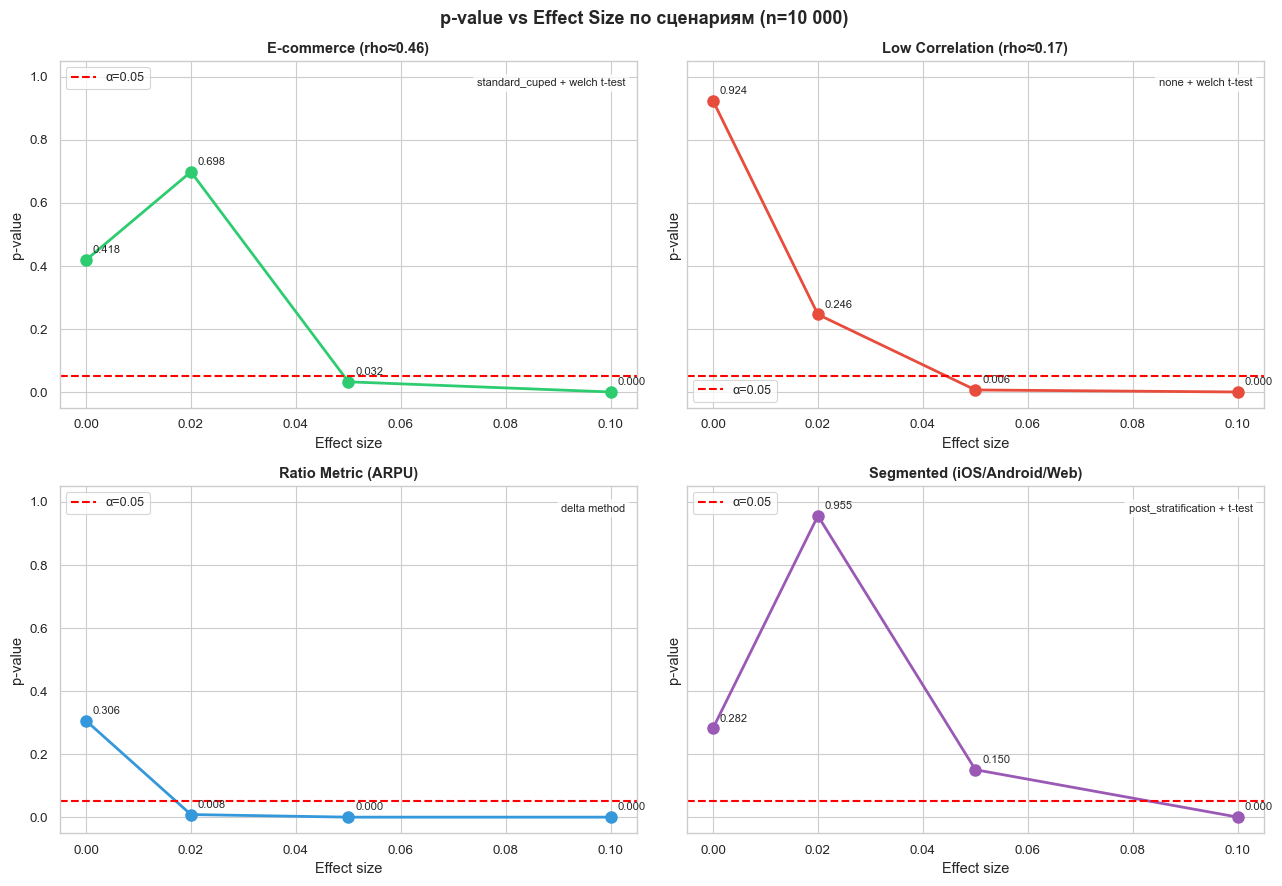

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
axes = axes.flatten()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']

for i, sc_cfg in enumerate(SCENARIOS):
    sc_name = sc_cfg['name']
    sub = df_results[df_results['scenario'] == sc_name]
    ax  = axes[i]

    ax.plot(sub['effect_size'], sub['p_value'],
            marker='o', linewidth=2, color=colors[i], markersize=8)
    ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='α=0.05')

    for _, row in sub.iterrows():
        ax.annotate(f'{row["p_value"]:.3f}',
                    (row['effect_size'], row['p_value']),
                    textcoords='offset points', xytext=(5, 5), fontsize=8)

    ax.set_title(sc_name, fontweight='bold')
    ax.set_xlabel('Effect size')
    ax.set_ylabel('p-value')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)

    method_short = sub.iloc[0]['method_used']
    ax.text(0.98, 0.95, method_short, transform=ax.transAxes,
            fontsize=8, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig.suptitle('p-value vs Effect Size по сценариям (n=10 000)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## Шаг 4: Снижение дисперсии по методам

/var/folders/y2/khyv_p956cgc_hm8pjzdjn_80000gn/T/ipykernel_14614/755745010.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(effect_05['scenario'], rotation=15, ha='right')


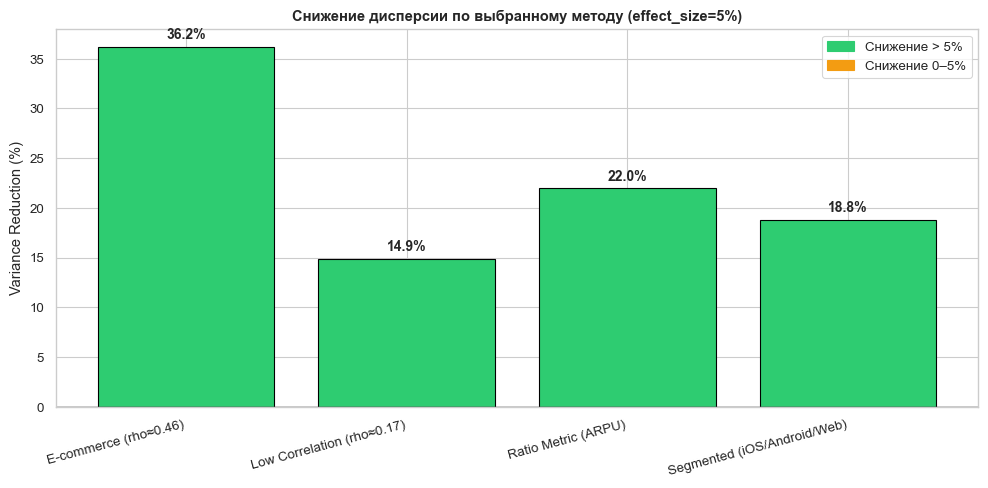

In [6]:
effect_05 = df_results[df_results['effect_size'] == 0.05].copy()

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#2ecc71' if v > 5 else '#e74c3c' if v < 0 else '#f39c12'
               for v in effect_05['variance_reduction']]

bars = ax.bar(effect_05['scenario'], effect_05['variance_reduction'],
              color=colors_bar, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, effect_05['variance_reduction']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.5 if val >= 0 else -1.5),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Variance Reduction (%)')
ax.set_title('Снижение дисперсии по выбранному методу (effect_size=5%)', fontweight='bold')
ax.set_xticklabels(effect_05['scenario'], rotation=15, ha='right')

green_patch = mpatches.Patch(color='#2ecc71', label='Снижение > 5%')
yellow_patch = mpatches.Patch(color='#f39c12', label='Снижение 0–5%')
ax.legend(handles=[green_patch, yellow_patch], loc='upper right')
plt.tight_layout()
plt.show()


## Итоговая таблица результатов

In [7]:
final = df_results[df_results['effect_size'] == 0.05][[
    'scenario', 'method_used', 'p_value', 'is_significant', 'variance_reduction'
]].copy()
final.columns = ['Сценарий', 'Метод', 'p-value', 'Значимо (α=5%)', 'Var.Reduction%']
final['p-value'] = final['p-value'].round(4)
final['Var.Reduction%'] = final['Var.Reduction%'].round(1)
print(final.to_string(index=False))


                   Сценарий                         Метод  p-value  Значимо (α=5%)  Var.Reduction%
      E-commerce (rho≈0.46) standard_cuped + welch t-test   0.0323            True            36.2
 Low Correlation (rho≈0.17)           none + welch t-test   0.0065            True            14.9
        Ratio Metric (ARPU)                  delta method   0.0000            True            22.0
Segmented (iOS/Android/Web)  post_stratification + t-test   0.1504           False            18.8
